In [4]:
import h5py 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
folder = r"../data/tests/01IB"

In [84]:
def set_ponk_number(filename):
    df = pd.read_csv(filename)
    df["ponk_number"] = 1 if filename.find("single") != -1 else [1, 2, 3] * int(df.shape[0]//3)
    df["stimulus_number"] = np.arange(df.shape[0]) if filename.find("single") != -1  else np.repeat(range(1, int(df.shape[0]//3)+1), 3)
    df.to_csv(filename)


filenames = [fl for fl in os.listdir(folder) if os.path.splitext(fl)[1] == ".csv"]
for fl in filenames:
    set_ponk_number(os.path.join(folder, fl))

In [123]:
for fl in filenames[:2]:
    df = pd.read_csv(os.path.join(folder, fl))
    df = df.drop(columns = ['Unnamed: 0.6'])
    df.to_csv(os.path.join(folder, fl), index=False)

In [132]:
def plot_error_plot(filename=None, df=None, ax=None, title=None):
    if filename is not None:
        df = pd.read_csv(filename)
    if df is None:
        return
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    legend_status = True if len(df["ponk_number"].unique()) > 1 else False
    sns.lineplot(df, x="stimulus_number", y="error", hue="ponk_number",marker="*", color='purple', ax=ax, legend=legend_status)
    ax.set_xticks(df["stimulus_number"].unique()[::5])
    ax.set_ylim(-400, 400)
    ax.set_ylabel("error [ms]")
    if title is not None:
        ax.set_title(title)
    ax.axhline(0, ls="--", linewidth=.5, color="black")
    return ax

<Axes: title={'center': 'SINGLE -- FEEDBACK'}, xlabel='stimulus_number', ylabel='error [ms]'>

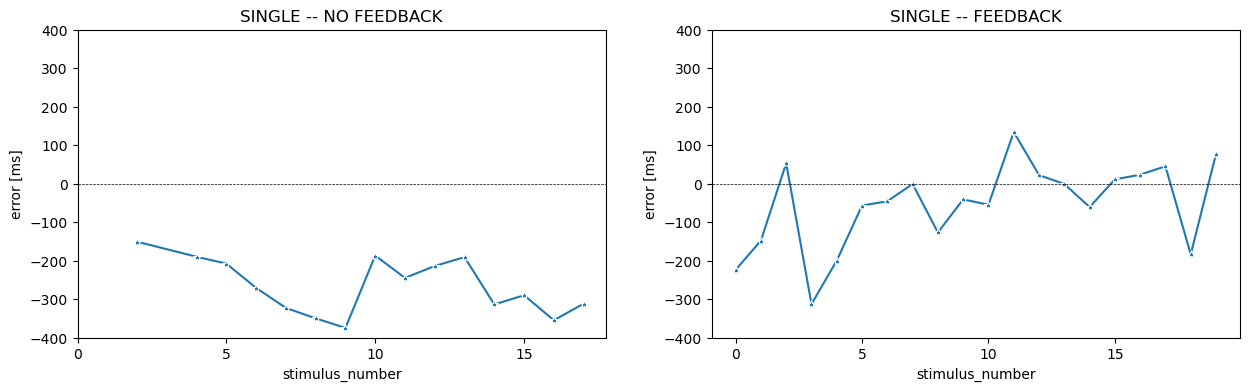

In [110]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
filename = os.path.join(folder, "01IB_01_single_NoFB.csv")
plot_error_plot(filename, ax[0], title="SINGLE -- NO FEEDBACK")
filename = os.path.join(folder, "01IB_02_single_FB.csv")
plot_error_plot(filename, ax[1], title="SINGLE -- FEEDBACK")

<Axes: title={'center': 'TRIPLETS -- FEEDBACK'}, xlabel='stimulus_number', ylabel='error [ms]'>

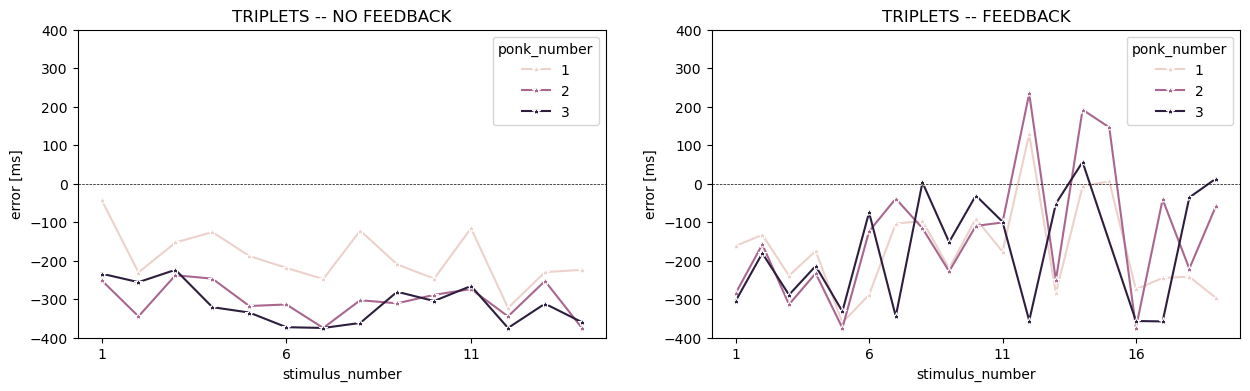

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
filename = os.path.join(folder, "01IB_03_triplets_NoFB.csv")
plot_error_plot(filename, ax[0], title="TRIPLETS -- NO FEEDBACK")
filename = os.path.join(folder, "01IB_04_triplets_FB-01.csv")
plot_error_plot(filename, ax[1], title="TRIPLETS -- FEEDBACK")

In [129]:
df_fb = []
n = 1
for filename in ['01IB_04_triplets_FB-01.csv', '01IB_05_triplets_FB-02.csv', '01IB_06_triplets_FB-03.csv', '01IB_07_triplets_FB-04.csv']:
    df = pd.read_csv(os.path.join(folder, filename))
    df["session_n"] = n
    n += 1
    df_fb.append(df)
df_fb = pd.concat(df_fb, ignore_index=True)
df_fb["stimulus_number"] = np.repeat(range(1, int(df_fb.shape[0]//3)+1), 3)

In [135]:
df_fb["session_n"].value_counts()

session_n
4    189
3    120
2     90
1     57
Name: count, dtype: int64

In [143]:
df = df_fb.copy()

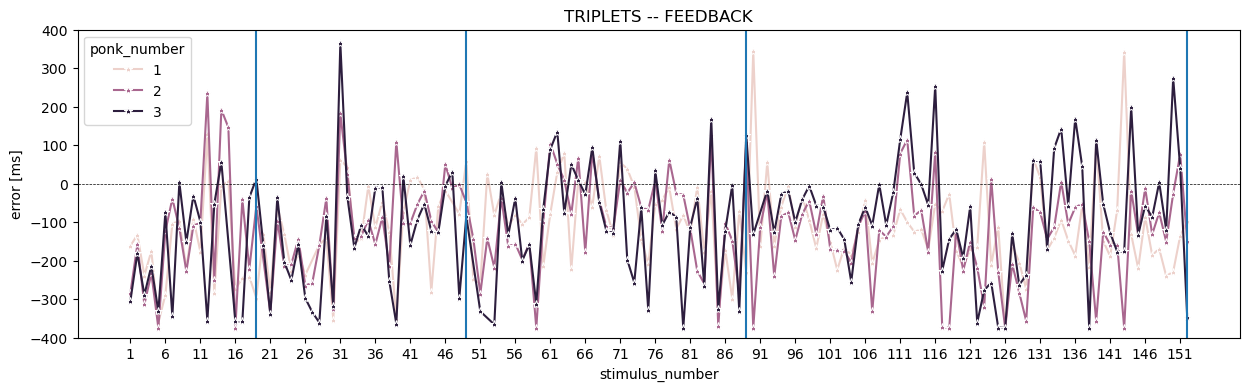

In [144]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plot_error_plot(df=df, title="TRIPLETS -- FEEDBACK", ax=ax)
for n in np.cumsum([57, 90, 120, 189])//3:
    ax.axvline(n)

<Axes: xlabel='error', ylabel='Count'>

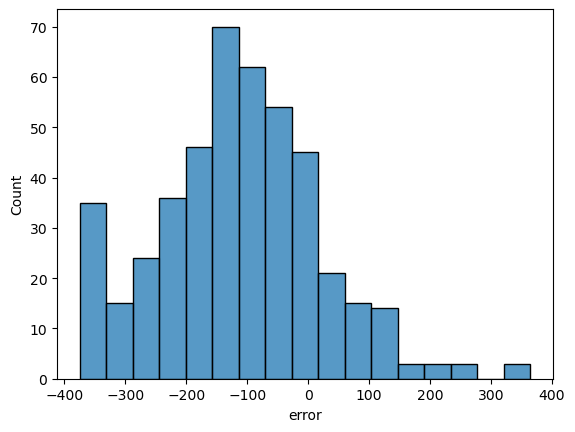

In [159]:
sns.histplot(df, x="error")

(-400.0, 400.0)

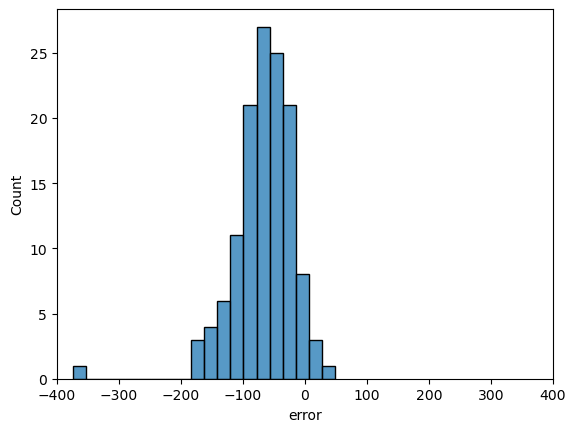

In [160]:
filename = os.path.join(r"../data/tests/02AV_eFB.csv")
df_a = pd.read_csv(filename)
sns.histplot(df_a, x="error")
plt.xlim(-400, 400)

<Axes: xlabel='session_n', ylabel='error'>

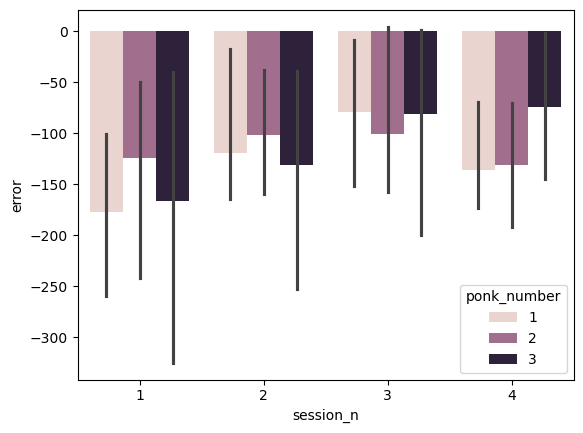

In [149]:
sns.barplot(df, x="session_n", y="error", hue="ponk_number", estimator="median", errorbar=("pi", 50))